### Imports

In [23]:
# Import necessary modules
from utils import *
import seaborn as sns
import utils.for_empatica as empatica
import utils.for_climate as climate
import pluma.schema.outdoor as outdoor

# Pluma-python API
from modules import *

In [2]:
# where getting raw and processed data from
rawdata = "/mnt/raid/emotional_data_raquel"

__________

### Check data location

In [3]:
datadir = os.path.join(rawdata, "data")

# find participants
participants = [
    p for p in os.listdir(datadir)
    if p.startswith("OE")
]
print(participants)

['OE011', 'OE015', 'OE019', 'OE010', 'OE024', 'OE018', 'OE005', 'OE004', 'OE007', 'OE022', 'OE021', 'OE020', 'OE009', 'OE012', 'OE002', 'OE017', 'OE023']


In [4]:
participant = participants[0]
participant_path = os.path.join(datadir, participant)
print(participant_path)

/mnt/raid/emotional_data_raquel/data/OE011


In [5]:
sessions = [
    s for s in os.listdir(participant_path)
    if os.path.isdir(os.path.join(participant_path, s))
]
print(sessions)

['Copenhagen_Nordhavn_sub-OE203011_2024-06-25T113254Z']


In [6]:
session = sessions[0]
session_path = os.path.join(participant_path, session)
print(session_path)

/mnt/raid/emotional_data_raquel/data/OE011/Copenhagen_Nordhavn_sub-OE203011_2024-06-25T113254Z


_________

## Data quality

In [7]:
base_dir = os.path.join(rawdata, "fulldata_mine")

good_participants = set()
bad_participants = set()

for sub in os.listdir(base_dir):
    sub_path = os.path.join(base_dir, sub)
    if not os.path.isdir(sub_path):
        continue

    participant_is_bad = False  # track per participant

    for ses in os.listdir(sub_path):
        ses_path = os.path.join(sub_path, ses)
        file_path = os.path.join(ses_path, "alldata.csv")

        if not os.path.exists(file_path):
            print(f"❌ MISSING FILE: {sub} - {ses}")
            participant_is_bad = True
            continue

        try:
            df = pd.read_csv(file_path)

            if df.empty:
                print(f"⚠️ EMPTY FILE:  {sub} - {ses}")
                participant_is_bad = True
            else:
                print(f"✅ OK:          {sub} - {ses} ({len(df)} rows)")

        except Exception as e:
            print(f"🔥 CORRUPT FILE: {sub} - {ses} | Error: {e}")
            participant_is_bad = True

    # after checking all sessions for this participant
    if participant_is_bad:
        bad_participants.add(sub)
    else:
        good_participants.add(sub)

✅ OK:          sub-OE020 - ses-Norrebro (1587 rows)
✅ OK:          sub-OE020 - ses-Nordhavn (1502 rows)
✅ OK:          sub-OE005 - ses-Nordhavn (1383 rows)
✅ OK:          sub-OE005 - ses-Hellerup (1499 rows)
✅ OK:          sub-OE018 - ses-Hellerup (1602 rows)
⚠️ EMPTY FILE:  sub-OE012 - ses-Norreport
✅ OK:          sub-OE021 - ses-Norrebro (1263 rows)
✅ OK:          sub-OE021 - ses-Hellerup (1601 rows)
✅ OK:          sub-OE015 - ses-Norreport (1465 rows)
✅ OK:          sub-OE002 - ses-Hellerup (1473 rows)
✅ OK:          sub-OE022 - ses-Norrebro (1484 rows)
✅ OK:          sub-OE022 - ses-Norreport (1545 rows)
✅ OK:          sub-OE022 - ses-Nordhavn (1432 rows)
✅ OK:          sub-OE009 - ses-Norrebro (1374 rows)
✅ OK:          sub-OE009 - ses-Nordhavn (1670 rows)
⚠️ EMPTY FILE:  sub-OE007 - ses-Hellerup
✅ OK:          sub-OE019 - ses-Hellerup (1796 rows)
⚠️ EMPTY FILE:  sub-OE017 - ses-Norreport
✅ OK:          sub-OE023 - ses-Norrebro (1520 rows)
✅ OK:          sub-OE023 - ses-Norreport 

___________

## Bad participants reasoning

In [8]:
results = []

for sub in bad_participants:
    sub_path = os.path.join(rawdata, "data", sub.replace("sub-", ""))  # careful with naming!

    if not os.path.exists(sub_path):
        print(f"❌ Missing participant folder: {sub}")
        continue

    for session_folder in os.listdir(sub_path):
        session_path = os.path.join(sub_path, session_folder)

        if not os.path.isdir(session_path):
            continue

        session_name = extract_session_name(session_folder)

        # ---- define paths ----
        empatica_data_path = os.path.join(
            rawdata, 'supp_mine', 'stress_csv', sub, f'ses-{session_name}', '_1hz', 'data_all_1Hz.csv'
        )

        geodata_data_path = os.path.join(
            rawdata, 'supp', 'geodata', 'log', sub, f'ses-{session_name}',
            f'{sub}_ses-{session_name}_geodata.xlsx'
        )

        gaze_data_path = os.path.join(
            rawdata, 'supp_mine', 'gaze', sub, f'ses-{session_name}', 'gaze.csv'
        )

        eeg_data_path = os.path.join(
            rawdata,
            'analysis-climate_physio_eeg_model_pipeline-outdoor_literature',
            sub, f'ses-{session_name}',
            'data', 'a01_psd_compute.m', 'eeg_power.xlsx'
        )

        # ---- check existence ----
        results.append({
            "participant": sub,
            "session": session_name,
            "empatica": os.path.exists(empatica_data_path),
            "geodata": os.path.exists(geodata_data_path),
            "gaze": os.path.exists(gaze_data_path),
            "eeg": os.path.exists(eeg_data_path),
        })

df_check = pd.DataFrame(results)

In [9]:
df_check

,participant,session,empatica,geodata,gaze,eeg
0,sub-OE012,Norreport,False,False,True,False
1,sub-OE017,Norreport,False,False,True,False
2,sub-OE007,Hellerup,False,False,True,False


Missing core streams (geodata + empatica + eeg)
➜ leads to empty merged dataset </p>

The current pipeline is:</p>

GEODATA → base timeline</p>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;↓</p>
EMPATICA → merged</p>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;↓</p>
GAZE → merged</p>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;↓</p>
EEG → merged</p>

Therefore, without geodata, NOTHING works

________

## Good participants

In [10]:
def check_streams(df):
    return {
        "gps": df["original_latitude"].notna().any() if "original_latitude" in df else False,

        "empatica_hr": df["E4_HR"].notna().any() if "E4_HR" in df else False,

        "eda": df["eda_raw"].notna().any() if "eda_raw" in df else False,

        "gaze": (
            df["GazeX"].notna().any() and df["GazeY"].notna().any()
            if "GazeX" in df and "GazeY" in df else False
        ),

        "eeg": (
            df["alpha"].notna().any()
            if "alpha" in df else False
        ),

        "climate": df["temp_atmospheric"].notna().any() if "temp_atmospheric" in df else False,
    }

In [11]:
results = []

for sub in good_participants:
    sub_path = os.path.join(base_dir, sub)

    for ses in os.listdir(sub_path):
        file_path = os.path.join(sub_path, ses, "alldata.csv")

        df = pd.read_csv(file_path)

        streams = check_streams(df)

        results.append({
            "participant": sub,
            "session": ses,
            **streams
        })

df_streams = pd.DataFrame(results)

In [12]:
df_streams

,participant,session,gps,empatica_hr,eda,gaze,eeg,climate
0,sub-OE021,ses-Norrebro,True,True,True,True,True,True
1,sub-OE021,ses-Hellerup,True,True,True,True,True,True
2,sub-OE018,ses-Hellerup,True,True,True,True,True,True
3,sub-OE022,ses-Norrebro,True,True,True,True,True,True
4,sub-OE022,ses-Norreport,True,True,True,True,True,True
5,sub-OE022,ses-Nordhavn,True,True,True,True,True,True
6,sub-OE019,ses-Hellerup,True,False,False,True,False,True
7,sub-OE009,ses-Norrebro,True,True,True,True,True,True
8,sub-OE009,ses-Nordhavn,True,True,True,True,True,True
9,sub-OE005,ses-Nordhavn,True,True,True,True,True,True


In [13]:
df_streams[
    (df_streams["empatica_hr"] == False) |
    (df_streams["gaze"] == False) |
    (df_streams["eeg"] == False)
]

,participant,session,gps,empatica_hr,eda,gaze,eeg,climate
6,sub-OE019,ses-Hellerup,True,False,False,True,False,True
13,sub-OE023,ses-Nordhavn,True,True,True,True,False,True
17,sub-OE015,ses-Norreport,True,False,False,True,False,True
18,sub-OE024,ses-Nordhavn,True,True,True,True,False,True
20,sub-OE010,ses-Nordhavn,True,True,True,True,False,True


________

### Heart rate (empatica) measures

In [14]:
keywords = ["hr", "heart", "bpm", "ibi", "pulse"]
cols = [col for col in df.columns if any(k in col.lower() for k in keywords)]
print(cols)

['E4_HR', 'empatica_heart_rate', 'HR', 'empatica_e4_hr', 'empatica_e4_ibi']


In [15]:
df[cols].describe()

,E4_HR,empatica_heart_rate,HR,empatica_e4_hr,empatica_e4_ibi
count,18.000000,18.000000,1477.000000,18.000000,18.000000
mean,115.299671,0.540390,110.492156,115.299671,0.540390
std,24.834171,0.090411,13.380036,24.834171,0.090411
min,89.298170,0.328140,76.923077,89.298170,0.328140
25%,101.118159,0.515649,98.387097,101.118159,0.515649
50%,105.332397,0.578152,115.384615,105.332397,0.578152
75%,116.358275,0.593777,120.000000,116.358275,0.593777
max,183.264250,0.671906,130.434783,183.264250,0.671906


_E4_HR_ and _empatica_e4_hr_ are the same </p>
_empatica_heart_rate_ and _empatica_e4_ibi_ are the same also </p>
_HR_ could be coming from the ECG device (because it has around 28% of missing values isntead of the 90% of the rest), however its values (mean ≈ 163 bpm & max = 200 bpm) are a bit suspicius

In [16]:
df[cols].isna().mean()

E4_HR                  0.987887
empatica_heart_rate    0.987887
HR                     0.006057
empatica_e4_hr         0.987887
empatica_e4_ibi        0.987887
dtype: float64

Turns out _HR_ is the ECG variable since this is what happens in for_empatica:

In [17]:
# data_all = pd.merge(data_all, data_hrlead[['DateTime', 'Bpm']].rename(columns={'Bpm': 'HR'}), on='DateTime', how='outer')

In [18]:
participant_path = "/mnt/raid/emotional_data_raquel/data/OE002"
session_folder = os.listdir(participant_path)[0]
session_path = os.path.join(participant_path, session_folder)

datapicker = create_datapicker(path=session_path, schema=build_schema)
dataset = load_dataset(datapicker.selected_path, schema=build_schema)

print(dataset.streams.BioData.ECG.data.keys())

Attempting to automatically correct eeg timestamps to harp timestamps...
Done.
odict_keys(['Raw', 'Filtered', 'Processed', 'HeartRate'])


<font color='red'>TODO: how to process the ECG data?</font>

In [19]:
ecg_raw = dataset.streams.BioData.ECG.data.Raw
ecg_raw.head()

,Value0,Value1
Seconds,,
2024-06-27 06:49:16.985737708,0,13
2024-06-27 06:49:16.986729708,0,14
2024-06-27 06:49:16.987721708,0,14
2024-06-27 06:49:16.988713708,0,15
2024-06-27 06:49:16.989737708,2191,13


In [20]:
ecg_signal = ecg_raw["Value0"].values
ecg_signal

array([   0,    0,    0, ..., 3915, 3915, 3915], dtype=uint16)

In [21]:
ecg_raw["Value0"].describe()

count    1.490880e+06
mean     2.129442e+03
std      1.389933e+03
min      0.000000e+00
25%      9.510000e+02
50%      2.318000e+03
75%      3.451000e+03
max      3.915000e+03
Name: Value0, dtype: float64

In [22]:
%matplotlib inline

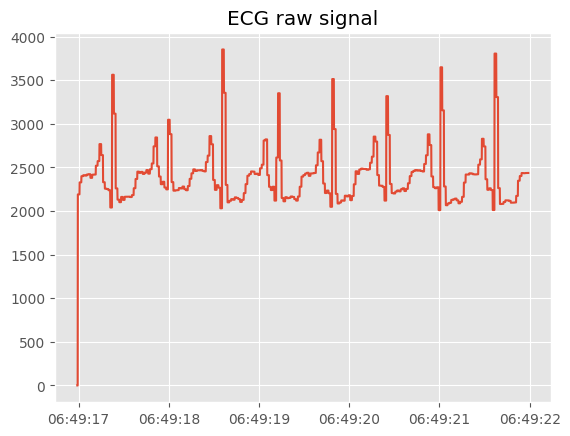

In [23]:
plt.plot(ecg_raw["Value0"][:5000])
plt.title("ECG raw signal")
plt.show()

__________

## Groups where category is all valid

In [24]:
groups = {
    "gps": ["gps"],
    "empatica": ["empatica_hr", "eda"],
    "eeg": ["eeg"],
    "gaze": ["gaze"],
    "climate": ["climate"]
}

group_variables = {
    "empatica": ["E4_HR", "empatica_heart_rate", "empatica_e4_hr", "HR",
                 "EDA_RAW", "EDA_PHASIC"],
    
    "eeg": ["frontal alpha", "frontal beta", "frontal theta"],
    
    "gaze": ["GazeX", "GazeY", "x_mean", "y_mean"],
    
    "gps": ["latitude", "longitude", "latitude_corrected", "longitude_corrected"],
    
    "climate": ["temp_atmos", "humidity", "wind_speed", "utci"]
}

In [25]:
valid_groups = {}

for name, cols in groups.items():
    valid_groups[name] = df_streams[df_streams[cols].all(axis=1)]

valid_groups["eeg"]

,participant,session,gps,empatica_hr,eda,gaze,eeg,climate
0,sub-OE021,ses-Norrebro,True,True,True,True,True,True
1,sub-OE021,ses-Hellerup,True,True,True,True,True,True
2,sub-OE018,ses-Hellerup,True,True,True,True,True,True
3,sub-OE022,ses-Norrebro,True,True,True,True,True,True
4,sub-OE022,ses-Norreport,True,True,True,True,True,True
5,sub-OE022,ses-Nordhavn,True,True,True,True,True,True
7,sub-OE009,ses-Norrebro,True,True,True,True,True,True
8,sub-OE009,ses-Nordhavn,True,True,True,True,True,True
9,sub-OE005,ses-Nordhavn,True,True,True,True,True,True
10,sub-OE005,ses-Hellerup,True,True,True,True,True,True


In [31]:
def collect_group_data(valid_df, variables, base_dir):
    dfs = []

    for _, row in valid_df.iterrows():
        sub = row["participant"]
        ses = row["session"]

        file_path = os.path.join(base_dir, sub, ses, "alldata.csv")

        try:
            df = pd.read_csv(file_path)

            # 🔥 FORCE all variables to exist
            for col in variables:
                if col not in df.columns:
                    df[col] = np.nan

            df = df[variables]

            df["participant"] = sub
            df["session"] = ses

            dfs.append(df)

        except:
            continue

    if len(dfs) == 0:
        return None

    return pd.concat(dfs, ignore_index=True)

In [32]:
def analyze_group(df, group_name):

    print(f"\n===== {group_name.upper()} =====")

    numeric_cols = df.select_dtypes(include=np.number).columns

    # ✅ Missing values
    print("\n--- Missing values ---")
    print(df[numeric_cols].isna().mean().sort_values(ascending=False))

    # ✅ Describe
    print("\n--- Describe ---")
    print(df[numeric_cols].describe())

    # ✅ Histograms
    df[numeric_cols].hist(figsize=(15, 10), bins=50)
    plt.suptitle(f"{group_name} - distributions")
    plt.show()

    # ✅ Boxplots (OUTLIERS 🔥)
    plt.figure(figsize=(15, 6))
    sns.boxplot(data=df[numeric_cols])
    plt.xticks(rotation=45)
    plt.title(f"{group_name} - boxplots (outliers)")
    plt.show()

In [33]:
%matplotlib inline

### Empatica analysis


===== EMPATICA =====

--- Missing values ---
EDA_RAW                1.000000
EDA_PHASIC             1.000000
E4_HR                  0.851108
empatica_heart_rate    0.851108
empatica_e4_hr         0.851108
HR                     0.192604
dtype: float64

--- Describe ---
             E4_HR  empatica_heart_rate  empatica_e4_hr            HR  \
count  4469.000000          4469.000000     4469.000000  24234.000000   
mean     95.733345             0.652649       95.733345    115.777089   
std      18.355145             0.132976       18.355145     39.588857   
min      51.889500             0.312514       51.889500     56.603774   
25%      83.474410             0.562526       83.474410     85.784314   
50%      95.995570             0.625029       95.995570    100.000000   
75%     106.744100             0.718783      106.744100    127.717391   
max     191.991200             1.156303      191.991200    200.000000   

       EDA_RAW  EDA_PHASIC  
count      0.0         0.0  
mean       Na

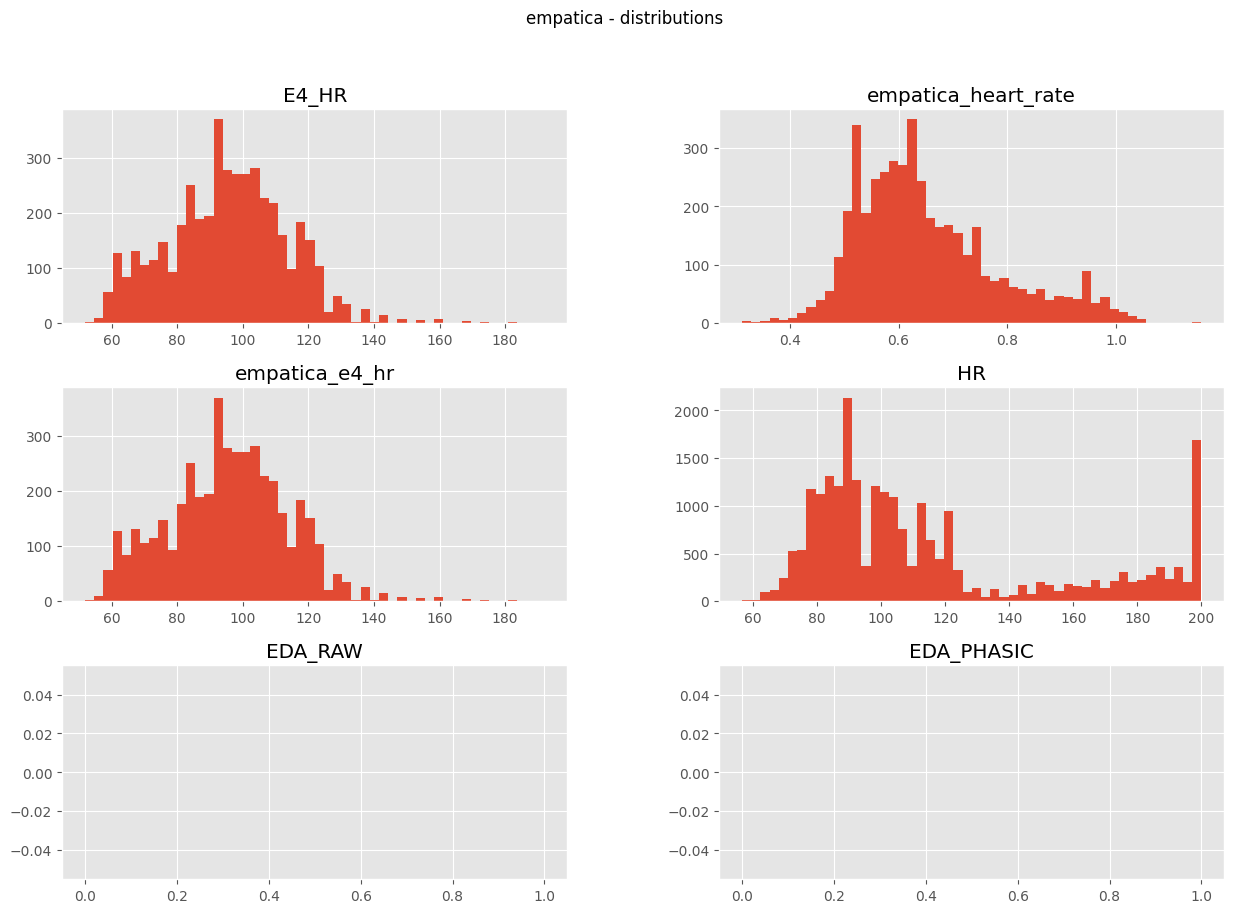

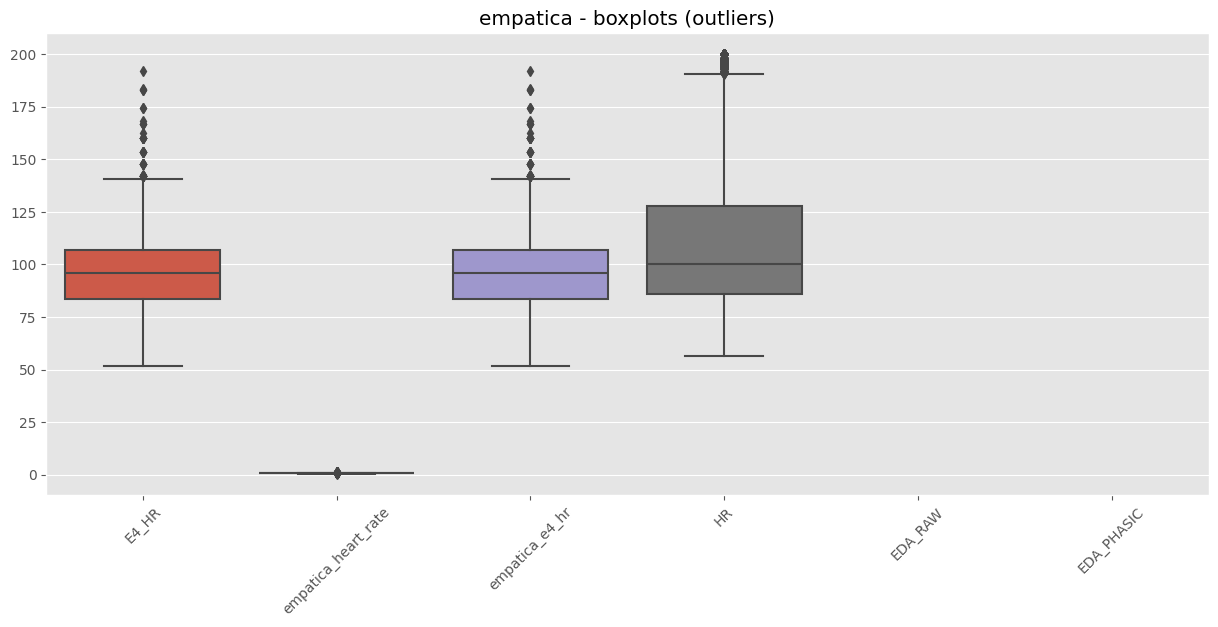

In [35]:
selected_group = "empatica"  # change this

variables = group_variables[selected_group]
valid_df = valid_groups[selected_group]

group_df = collect_group_data(valid_df, variables, base_dir)

if group_df is not None:
    analyze_group(group_df, selected_group)

### EEG analysis


===== EEG =====

--- Missing values ---
frontal beta     1.000000
frontal alpha    0.151549
frontal theta    0.151549
dtype: float64

--- Describe ---
       frontal alpha  frontal beta  frontal theta
count   2.153200e+04           0.0   2.153200e+04
mean    4.078921e+00           NaN   4.643345e+00
std     3.767319e+00           NaN   4.531902e+00
min     1.290381e-13           NaN   2.620181e-12
25%     1.331388e+00           NaN   1.834225e+00
50%     3.043936e+00           NaN   3.370083e+00
75%     5.466831e+00           NaN   5.979836e+00
max     3.806312e+01           NaN   1.073683e+02


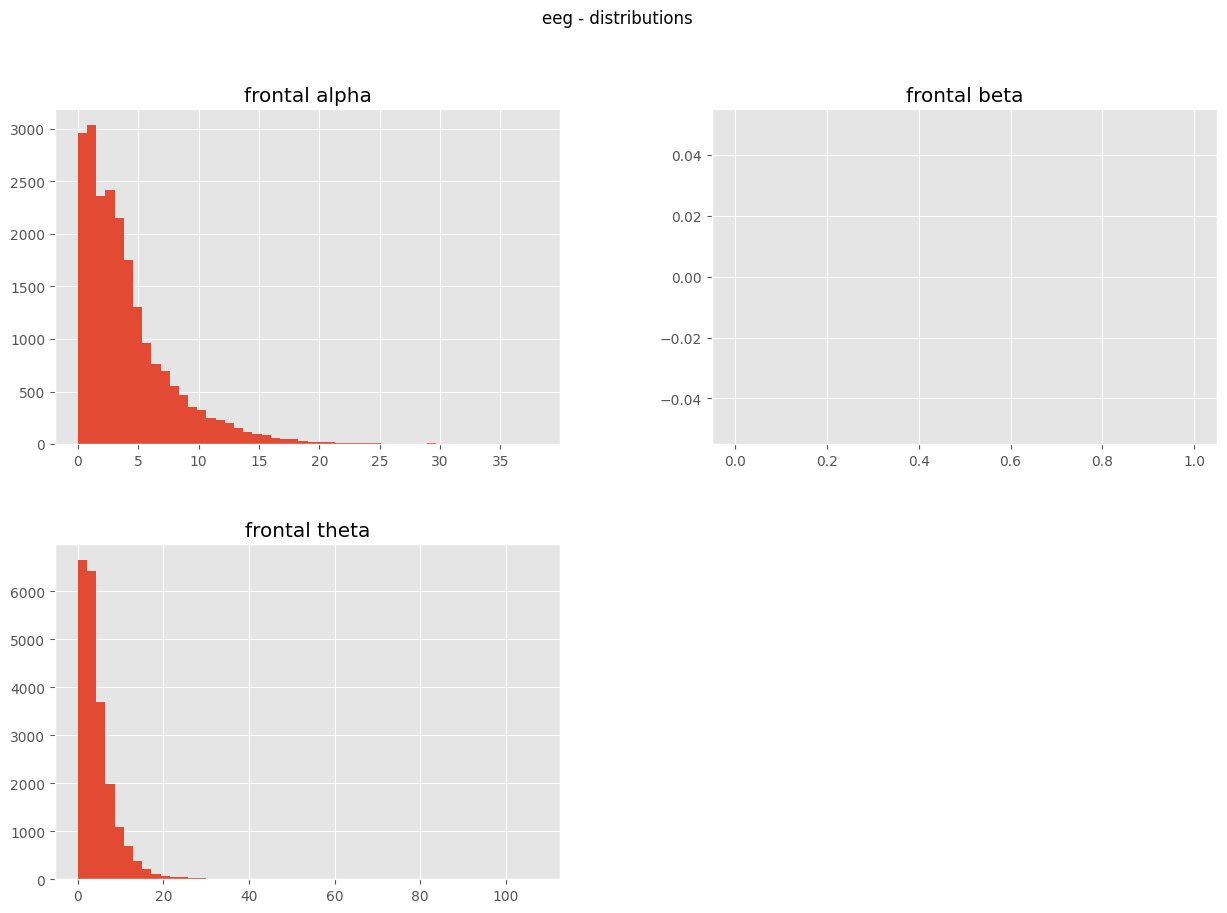

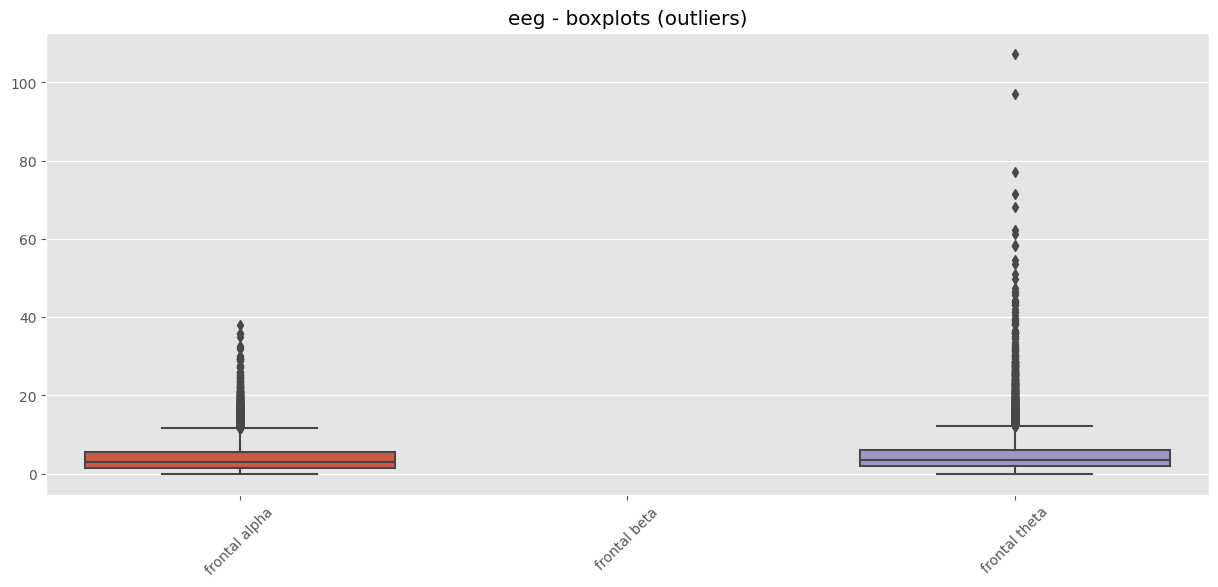

In [36]:
selected_group = "eeg"  # change this

variables = group_variables[selected_group]
valid_df = valid_groups[selected_group]

group_df = collect_group_data(valid_df, variables, base_dir)

if group_df is not None:
    analyze_group(group_df, selected_group)

### Gaze analysis


===== GAZE =====

--- Missing values ---
x_mean    1.000000
y_mean    1.000000
GazeX     0.061696
GazeY     0.061696
dtype: float64

--- Describe ---
              GazeX         GazeY  x_mean  y_mean
count  31223.000000  31223.000000     0.0     0.0
mean     446.627746    494.281113     NaN     NaN
std      174.745662    157.920116     NaN     NaN
min     -171.155560     54.368748     NaN     NaN
25%      354.160410    384.520650     NaN     NaN
50%      446.430800    470.497700     NaN     NaN
75%      543.192995    578.686470     NaN     NaN
max     1166.226600   1114.157200     NaN     NaN


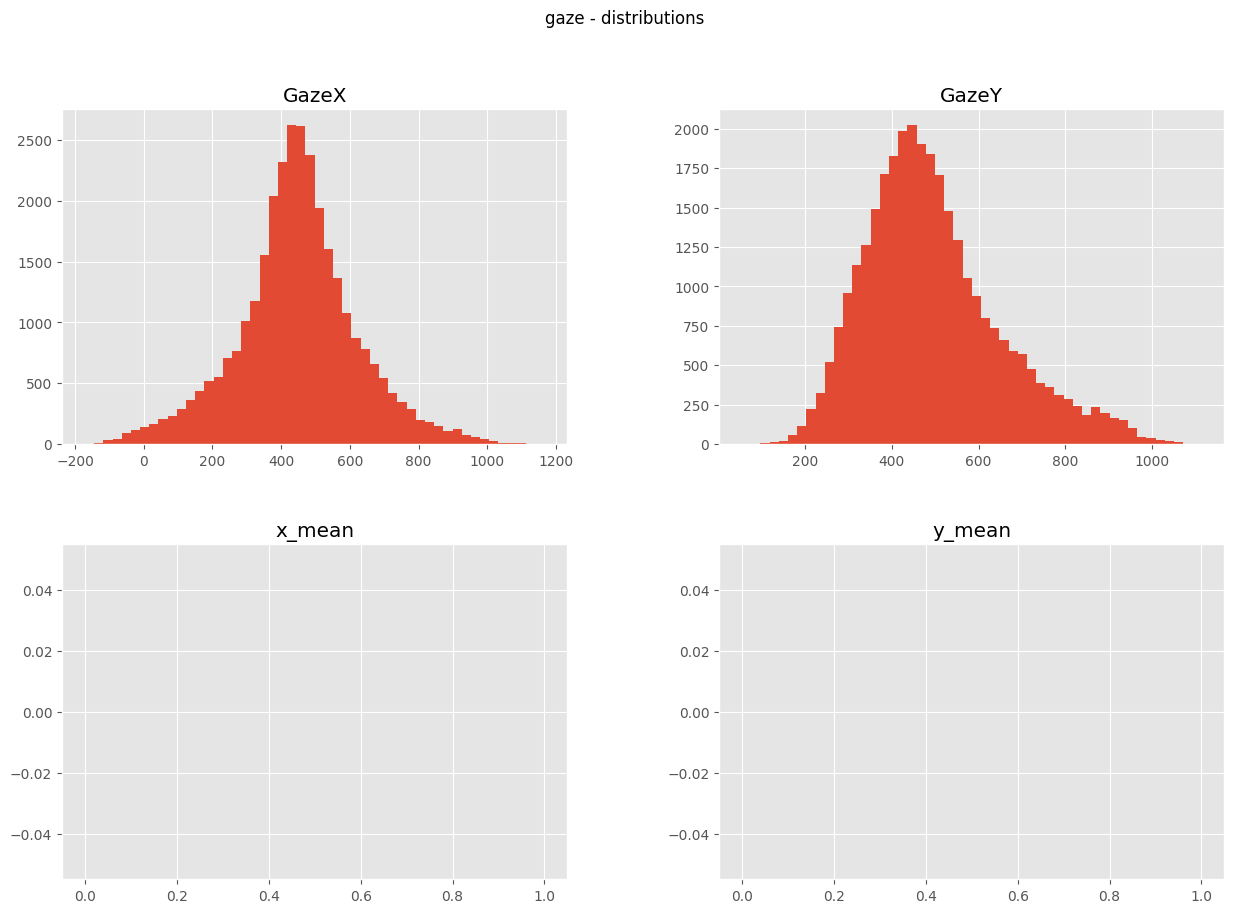

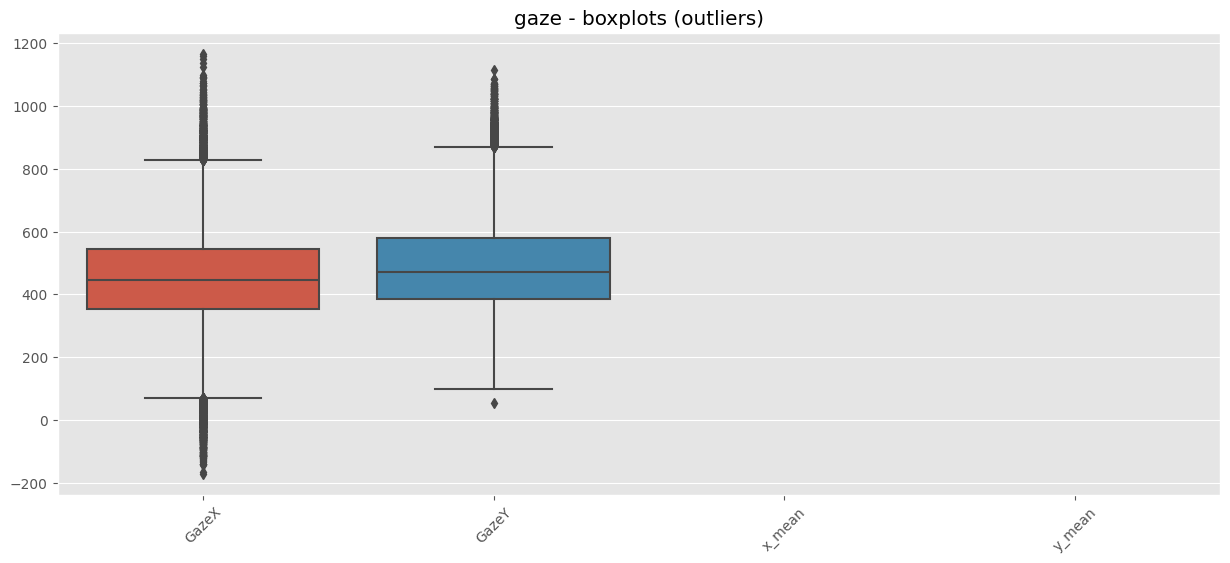

In [37]:
selected_group = "gaze"  # change this

variables = group_variables[selected_group]
valid_df = valid_groups[selected_group]

group_df = collect_group_data(valid_df, variables, base_dir)

if group_df is not None:
    analyze_group(group_df, selected_group)

### GPS analysis


===== GPS =====

--- Missing values ---
latitude               1.000000
longitude              1.000000
latitude_corrected     0.355151
longitude_corrected    0.355151
dtype: float64

--- Describe ---
       latitude  longitude  latitude_corrected  longitude_corrected
count       0.0        0.0        21458.000000         21458.000000
mean        NaN        NaN           55.706381            12.577264
std         NaN        NaN            0.017622             0.015586
min         NaN        NaN           55.681724            12.537772
25%         NaN        NaN           55.683746            12.568132
50%         NaN        NaN           55.706529            12.576133
75%         NaN        NaN           55.728138            12.590842
max         NaN        NaN           55.730722            12.598776


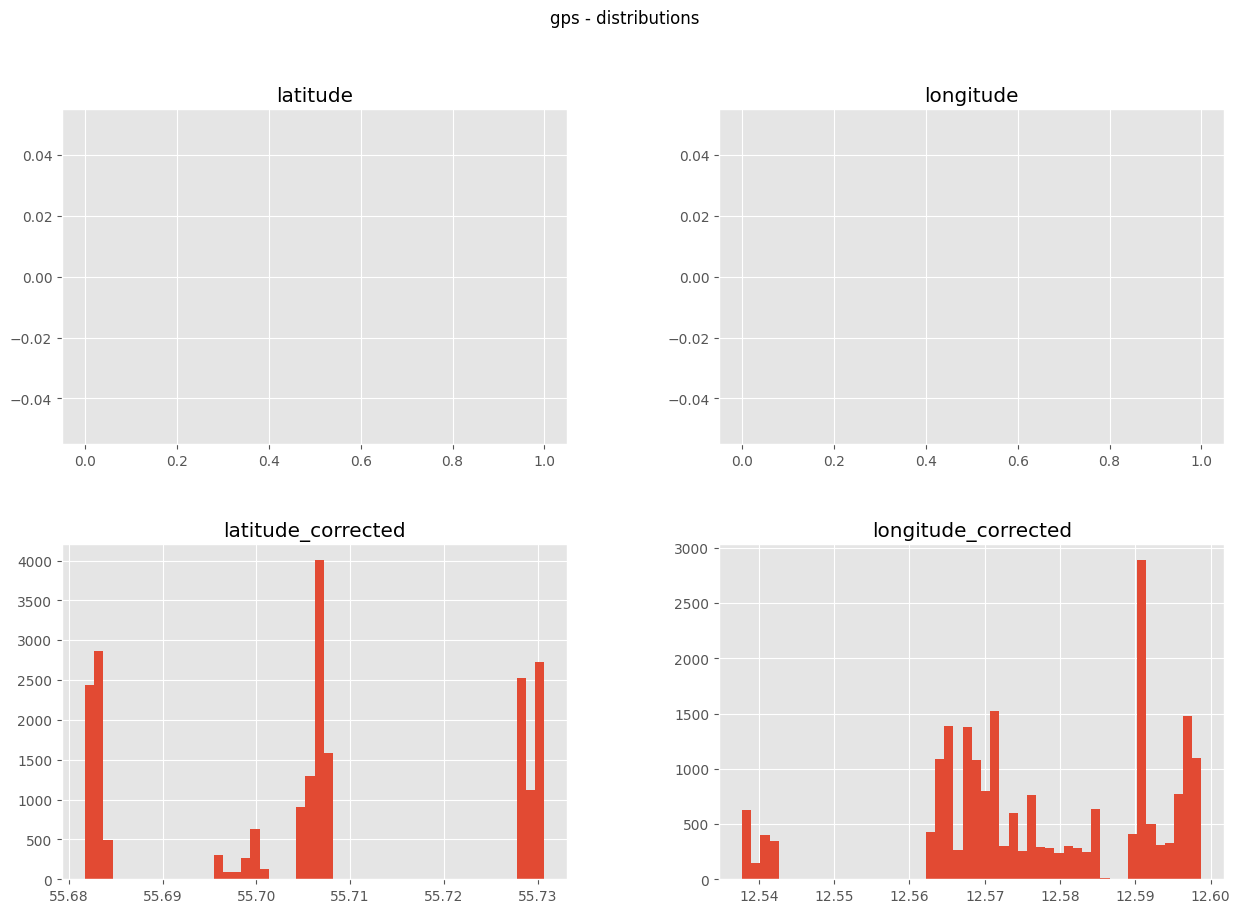

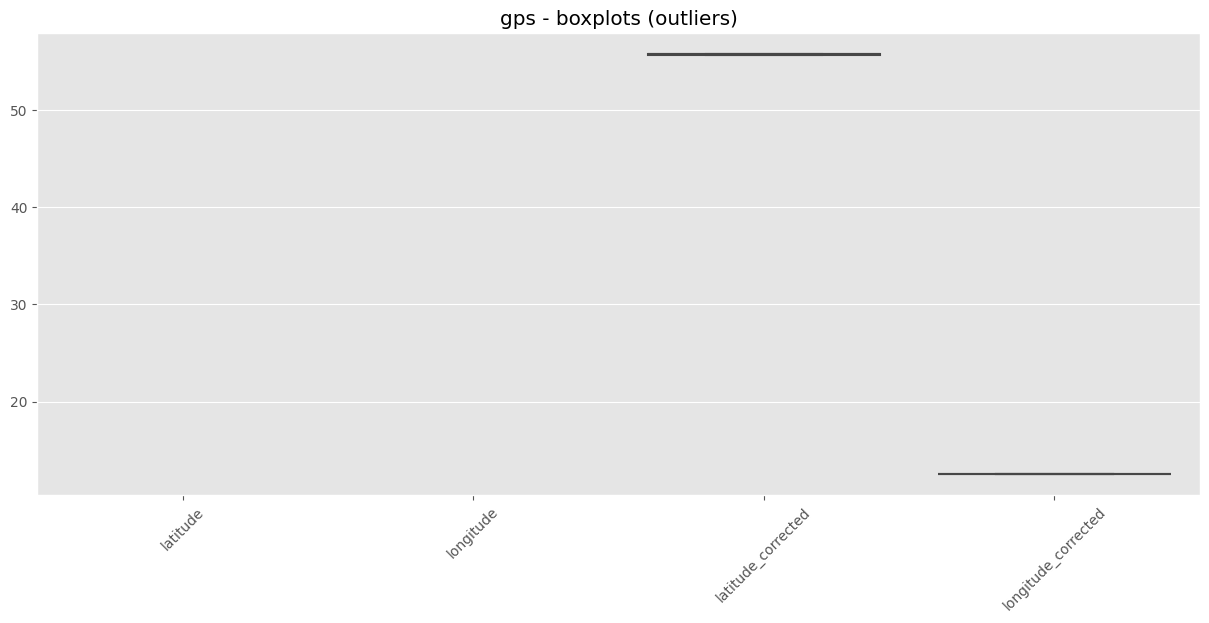

In [38]:
selected_group = "gps"  # change this

variables = group_variables[selected_group]
valid_df = valid_groups[selected_group]

group_df = collect_group_data(valid_df, variables, base_dir)

if group_df is not None:
    analyze_group(group_df, selected_group)

### Climate analysis


===== CLIMATE =====

--- Missing values ---
temp_atmos    1.000000
utci          1.000000
wind_speed    0.007904
humidity      0.001412
dtype: float64

--- Describe ---
       temp_atmos      humidity    wind_speed  utci
count         0.0  33229.000000  33013.000000   0.0
mean          NaN     67.152157      1.492068   NaN
std           NaN     12.869878      0.940701   NaN
min           NaN     47.190000      0.005000   NaN
25%           NaN     57.865600      0.784474   NaN
50%           NaN     63.867200      1.330883   NaN
75%           NaN     74.846800      2.024846   NaN
max           NaN     99.990000      8.977723   NaN


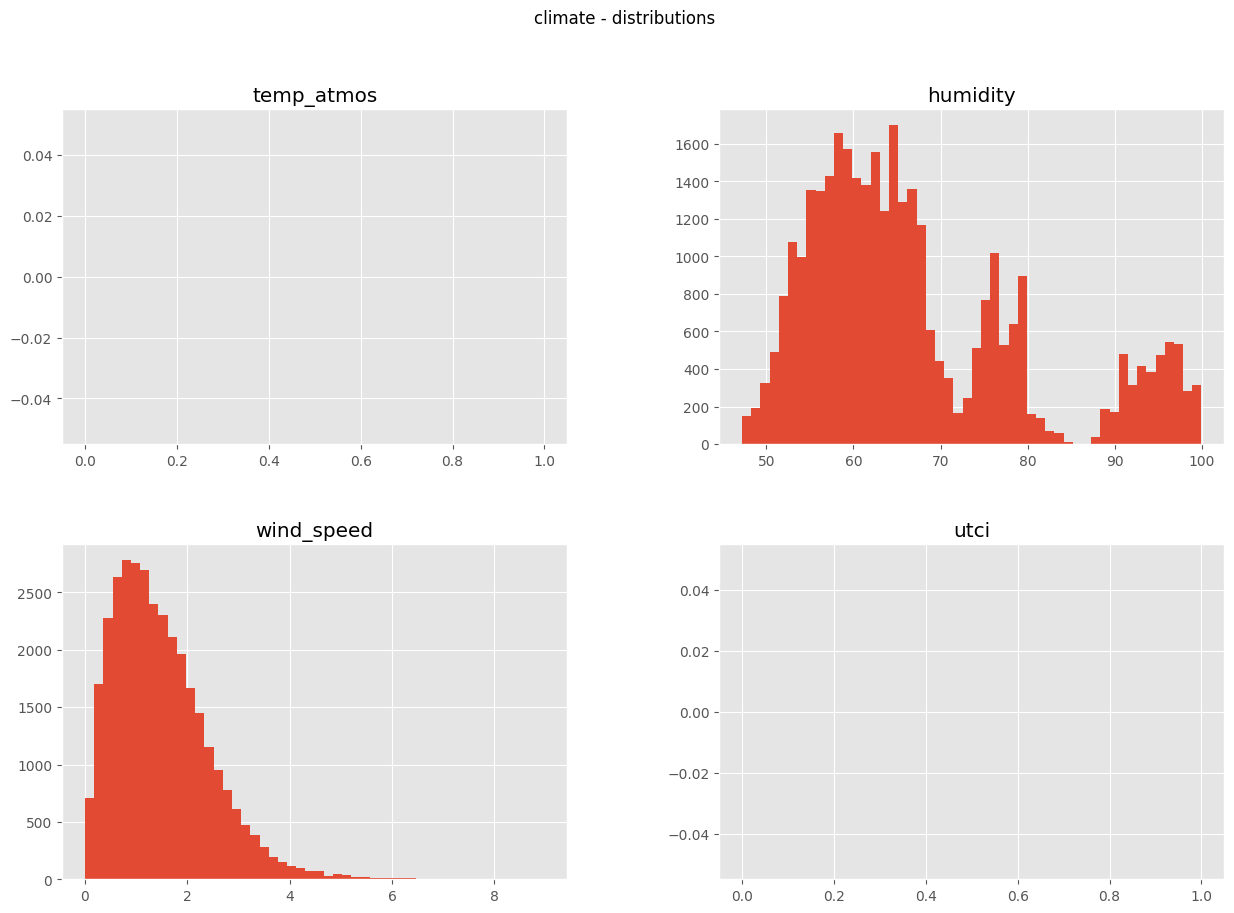

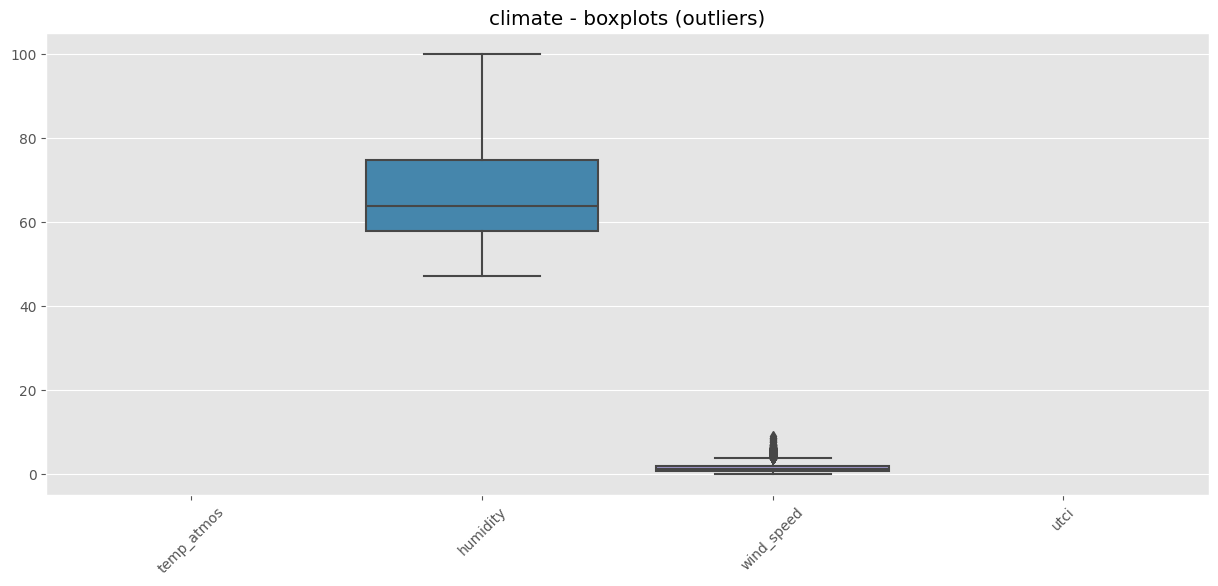

In [39]:
selected_group = "climate"  # change this

variables = group_variables[selected_group]
valid_df = valid_groups[selected_group]

group_df = collect_group_data(valid_df, variables, base_dir)

if group_df is not None:
    analyze_group(group_df, selected_group)

In [40]:
# for group_name, variables in group_variables.items():

#     valid_df = valid_groups[group_name]

#     group_df = collect_group_data(valid_df, variables, base_dir)

#     if group_df is not None:
#         analyze_group(group_df, group_name)